# ThisCompany Headline Ranking by +5-Bar Return

Ranks headline **templates** by subsequent 5-bar return, using only rows where `ThisCompany == 1`.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FEATURES_PATH = Path('headline_features.parquet')
BARS_PATHS = [
    Path('hrt-eth-zurich-datathon-2026/data/bars_seen_train.parquet'),
    Path('hrt-eth-zurich-datathon-2026/data/bars_unseen_train.parquet'),
]

K = 10
MIN_COUNT = 50  # increase if you want fewer, more stable bars
THIS_COMPANY_FILTER = None   # True / False / None
THIS_SECTOR_FILTER = None    # True / False / None

def _label(name: str, value):
    if value is None:
        return f'{name}_all'
    return f'{name}_{str(bool(value)).lower()}'

FILTER_LABEL = f"{_label('thiscompany', THIS_COMPANY_FILTER)}_{_label('thissector', THIS_SECTOR_FILTER)}"

OUT_DIR = Path('plots')
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / f'headline_template_returns_{FILTER_LABEL}_k{K}.png'

if not FEATURES_PATH.exists():
    raise FileNotFoundError(f'{FEATURES_PATH.resolve()} not found')
for p in BARS_PATHS:
    if not p.exists():
        raise FileNotFoundError(f'{p.resolve()} not found')

print('Features:', FEATURES_PATH.resolve())
print('ThisCompany filter:', THIS_COMPANY_FILTER)
print('ThisSector filter:', THIS_SECTOR_FILTER)
print('Output:', OUT_PATH.resolve())


Features: /Users/lukawedegartner/Documents/eth/Datathon/headline_features.parquet
ThisCompany filter: None
ThisSector filter: None
Output: /Users/lukawedegartner/Documents/eth/Datathon/plots/headline_template_returns_thiscompany_all_thissector_all_k5.png


In [ ]:
features = pd.read_parquet(FEATURES_PATH)
bars = pd.concat([pd.read_parquet(p) for p in BARS_PATHS], ignore_index=True)
bars = bars.sort_values(['session', 'bar_ix']).reset_index(drop=True)

if 'ThisCompany' not in features.columns:
    raise KeyError('ThisCompany column not found in features file')
if 'ThisSector' not in features.columns:
    raise KeyError('ThisSector column not found in features file')

sub = features.copy()

if THIS_COMPANY_FILTER is not None:
    company_target = 1 if bool(THIS_COMPANY_FILTER) else 0
    this_company = pd.to_numeric(sub['ThisCompany'], errors='coerce').fillna(0).astype(int)
    sub = sub[this_company == company_target].copy()

if THIS_SECTOR_FILTER is not None:
    sector_target = 1 if bool(THIS_SECTOR_FILTER) else 0
    this_sector = pd.to_numeric(sub['ThisSector'], errors='coerce').fillna(0).astype(int)
    sub = sub[this_sector == sector_target].copy()

if sub.empty:
    raise ValueError(
        f'No rows for filters ThisCompany={THIS_COMPANY_FILTER}, ThisSector={THIS_SECTOR_FILTER}'
    )

close = bars.set_index(['session', 'bar_ix'])['close'].sort_index()
max_bar_per_session = bars.groupby('session')['bar_ix'].max()

sub['session'] = pd.to_numeric(sub['session'], errors='coerce').astype('Int64')
sub['bar_ix'] = pd.to_numeric(sub['bar_ix'], errors='coerce').astype('Int64')
sub = sub.dropna(subset=['session', 'bar_ix']).copy()
sub['session'] = sub['session'].astype(int)
sub['bar_ix'] = sub['bar_ix'].astype(int)

sub['c0'] = close.reindex(list(zip(sub['session'], sub['bar_ix']))).values
end_bars = np.minimum(sub['bar_ix'] + K, sub['session'].map(max_bar_per_session))
sub['c1'] = close.reindex(list(zip(sub['session'], end_bars))).values
sub['fwd_ret'] = sub['c1'] / sub['c0'] - 1
sub = sub.dropna(subset=['fwd_ret'])

label_col = 'template_text' if 'template_text' in sub.columns else 'template_index'
agg = sub.groupby(label_col)['fwd_ret'].agg(['count', 'mean', 'std']).reset_index()
agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0.0)
agg = agg[agg['count'] >= MIN_COUNT].sort_values('mean').reset_index(drop=True)

if agg.empty:
    raise ValueError(
        f'No groups left after MIN_COUNT={MIN_COUNT} and filters '
        f'ThisCompany={THIS_COMPANY_FILTER}, ThisSector={THIS_SECTOR_FILTER}'
    )

print('Rows in subset:', len(sub))
print('Templates plotted:', len(agg))
agg.head()


Rows in subset: 17371
Templates plotted: 41


,template_text,count,mean,std,sem
0,<COMPANY> withdraws from <REGION> market citin...,322,-0.001812,0.006244,0.000348
1,<COMPANY> loses key contract in <REGION> to co...,339,-0.001773,0.006741,0.000366
2,<COMPANY> misses quarterly revenue estimates b...,425,-0.001748,0.006692,0.000325
3,<COMPANY> sees N% drop in new customer orders ...,401,-0.001648,0.006914,0.000345
4,<COMPANY> warns of <SECTOR> disruptions affect...,337,-0.001520,0.006858,0.000374


Saved plot: /Users/lukawedegartner/Documents/eth/Datathon/plots/headline_template_returns_thiscompany_all_thissector_all_k5.png


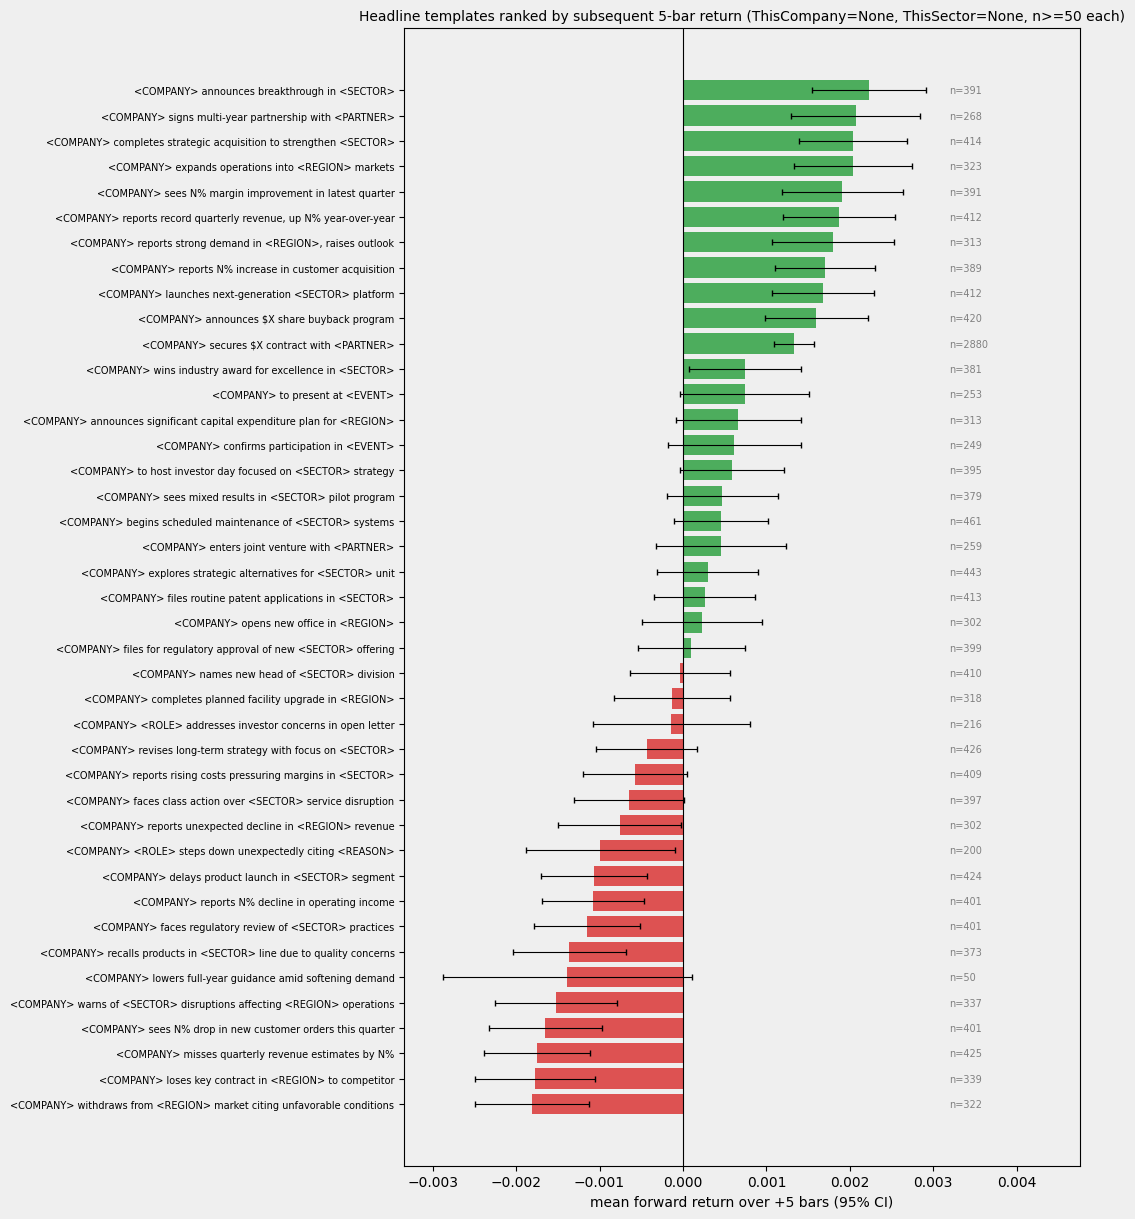

In [ ]:
fig_h = max(8, 0.30 * len(agg))
fig, ax = plt.subplots(figsize=(11, fig_h))
fig.patch.set_facecolor('#efefef')
ax.set_facecolor('#efefef')

y = np.arange(len(agg))
colors = ['#44aa55' if m >= 0 else '#dd4a4a' for m in agg['mean']]
xerr = 1.96 * agg['sem']

ax.barh(
    y,
    agg['mean'],
    xerr=xerr,
    color=colors,
    alpha=0.95,
    ecolor='black',
    capsize=2,
    error_kw={'elinewidth': 0.8},
)
ax.axvline(0, color='black', linewidth=0.8)

labels = [str(t) for t in agg[label_col]]
labels = [t if len(t) <= 80 else t[:79] + '…' for t in labels]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=7)

left = float((agg['mean'] - xerr).min())
right = float((agg['mean'] + xerr).max())
span = (right - left) if right > left else 1e-6
pad = span * 0.08
ax.set_xlim(left - pad, right + pad * 4)

count_x = right + pad * 0.6
for yi, n in zip(y, agg['count']):
    ax.text(count_x, yi, f'n={int(n)}', va='center', fontsize=7, color='gray')

ax.set_xlabel(f'mean forward return over +{K} bars (95% CI)')
ax.set_title(
    f'Headline templates ranked by subsequent {K}-bar return '
    f'(ThisCompany={THIS_COMPANY_FILTER}, ThisSector={THIS_SECTOR_FILTER}, n>={MIN_COUNT} each)',
    fontsize=10,
)

plt.tight_layout()
fig.savefig(OUT_PATH, dpi=140, bbox_inches='tight')
print('Saved plot:', OUT_PATH.resolve())
plt.show()
